**Prérequis : `03_preparation_gold.ipynb`** exécuté (Gold disponible dans `data/gold/`).
Indépendant de `04_modelisation_churn.ipynb` (cible différente), mais réutilise le
même jeu de features et le même split.

---

# TP7 — Régression de la valeur vie client (`valeur_vie_client_eur`)

**Cas d'usage :** cible secondaire du projet churn -- éditeur SaaS B2B.

**Portée de ce notebook [C4-C5, cible secondaire].** Prédire `valeur_vie_client_eur`
en régression, pour enrichir l'analyse métier -- **jamais comme feature du modèle
de churn** (rappel énoncé §3.2 : "*ne PAS l'utiliser comme variable explicative du
modèle principal*"). Même structure de démarche que le notebook 04 : baseline,
comparaison de deux familles de modèles, sélection, lecture des facteurs.

**Ce que ce notebook réutilise du cadrage précédent :**
- **Features identiques au modèle churn** (`gold_manifest.json`,
  `cible_secondaire_features.feature_columns_clv`) -- même principe anti-fuite
  appliqué à `sante_compte_fin_periode` et `churn`, exclues par disponibilité au
  scoring et non par force de corrélation (notebook 03, §8).
- **`commentaire_csm` déjà absent de Gold** (D7, atelier de cadrage n°1).


In [1]:
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

GOLD_DIR = Path("../data/gold")
MODEL_DIR = Path("../data/model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_AT = datetime.now(timezone.utc).isoformat()
RANDOM_STATE = 42

gold = pd.read_parquet(GOLD_DIR / "clients_churn_gold.parquet")
with open(GOLD_DIR / "gold_manifest.json", "r", encoding="utf-8") as f:
    gold_manifest = json.load(f)

feature_columns = gold_manifest["cible_secondaire_features"]["feature_columns_clv"]

assert "sante_compte_fin_periode" not in feature_columns, "Exclusion anti-fuite non respectée"
assert "churn" not in feature_columns, "La cible principale ne doit pas nourrir la régression CLV"
assert "commentaire_csm" not in gold.columns, "commentaire_csm ne doit même pas être en Gold (D7)"

print(f"Gold : {gold.shape[0]} lignes")
print(f"Features pour la régression CLV : {len(feature_columns)} (identiques à X_churn : "
      f"{gold_manifest['cible_secondaire_features']['identique_a_feature_columns_modele_principal']})")
print("Vérifications anti-fuite : OK")

Gold : 5000 lignes
Features pour la régression CLV : 30 (identiques à X_churn : True)
Vérifications anti-fuite : OK


## §0 — Train/test (même split que le modèle churn) et distribution de la cible

Même colonne `split` réutilisée -- un compte du jeu de test du modèle churn reste
dans le jeu de test de la régression CLV, pas de fuite d'information entre les deux
évaluations.

In [2]:
train = gold[gold["split"] == "train"]
test = gold[gold["split"] == "test"]

X_train, y_train = train[feature_columns], train["valeur_vie_client_eur"].astype(float)
X_test, y_test = test[feature_columns], test["valeur_vie_client_eur"].astype(float)

cat_cols = [c for c in feature_columns if not pd.api.types.is_numeric_dtype(gold[c])]
num_cols = [c for c in feature_columns if c not in cat_cols]

print(y_train.describe().round(0))
print()
print(f"Asymétrie (skew) de la cible brute : {y_train.skew():.2f}")
print(f"Asymétrie (skew) de log(1+cible)   : {np.log1p(y_train).skew():.2f}")
print()
print("=> Cible très étalée (300 € à ~2 M€) -- les modèles sont entraînés sur")
print("   log(1+valeur_vie_client_eur), les prédictions sont retransformées en euros")
print("   (expm1) avant de calculer RMSE/MAE/R² -- pour rester interprétable côté métier.")

count       4000.0
mean       72373.0
std       201199.0
min          300.0
25%         2492.0
50%        11086.0
75%        44936.0
max      2000000.0
Name: valeur_vie_client_eur, dtype: float64

Asymétrie (skew) de la cible brute : 5.63
Asymétrie (skew) de log(1+cible)   : 0.17

=> Cible très étalée (300 € à ~2 M€) -- les modèles sont entraînés sur
   log(1+valeur_vie_client_eur), les prédictions sont retransformées en euros
   (expm1) avant de calculer RMSE/MAE/R² -- pour rester interprétable côté métier.


## §1 — Baseline

Un `DummyRegressor` qui prédit systématiquement la médiane du train -- le plancher
que tout modèle doit dépasser.

In [3]:
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

def evaluer(y_true, y_pred, nom):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    print(f"{nom} -- RMSE : {rmse:,.0f} € | MAE : {mae:,.0f} € | R² : {r2:.3f}")
    return {"rmse_eur": round(rmse, 0), "mae_eur": round(mae, 0), "r2": round(r2, 3)}

metriques_baseline = evaluer(y_test, pred_baseline, "Baseline (médiane)")

Baseline (médiane) -- RMSE : 244,135 € | MAE : 81,809 € | R² : -0.102


## §2 — Modèle 1 : régression Ridge sur `log(1 + valeur_vie_client_eur)`

Régularisation L2 -- limite le poids des catégories rares après one-hot, plus
stable qu'une régression linéaire simple sur ce jeu de features.

In [4]:
preprocessor_lin = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

pipe_ridge = Pipeline([
    ("prep", preprocessor_lin),
    ("reg", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
pipe_ridge.fit(X_train, np.log1p(y_train))
pred_ridge = np.expm1(pipe_ridge.predict(X_test))
pred_ridge = np.clip(pred_ridge, 0, None)

metriques_ridge = evaluer(y_test, pred_ridge, "Ridge (log-cible)")

cv_ridge = cross_val_score(
    pipe_ridge, X_train, np.log1p(y_train), cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="r2",
)
print(f"Validation croisée (5 folds, train, R² en espace log) : {cv_ridge.mean():.3f} +/- {cv_ridge.std():.3f}")

Ridge (log-cible) -- RMSE : 185,679 € | MAE : 50,438 € | R² : 0.362
Validation croisée (5 folds, train, R² en espace log) : 0.804 +/- 0.015


## §3 — Modèle 2 : forêt aléatoire sur `log(1 + valeur_vie_client_eur)`

In [5]:
preprocessor_rf = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

pipe_rf_reg = Pipeline([
    ("prep", preprocessor_rf),
    ("reg", RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
pipe_rf_reg.fit(X_train, np.log1p(y_train))
pred_rf_reg = np.expm1(pipe_rf_reg.predict(X_test))
pred_rf_reg = np.clip(pred_rf_reg, 0, None)

metriques_rf = evaluer(y_test, pred_rf_reg, "Forêt aléatoire (log-cible)")

cv_rf_reg = cross_val_score(
    pipe_rf_reg, X_train, np.log1p(y_train), cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="r2",
)
print(f"Validation croisée (5 folds, train, R² en espace log) : {cv_rf_reg.mean():.3f} +/- {cv_rf_reg.std():.3f}")

Forêt aléatoire (log-cible) -- RMSE : 128,038 € | MAE : 40,615 € | R² : 0.697


Validation croisée (5 folds, train, R² en espace log) : 0.887 +/- 0.008


## §4 — Comparaison, sélection et diagnostic visuel

Sélection sur le **MAE** plutôt que le RMSE : avec une cible aussi étalée (quelques
comptes à >500k€), le RMSE est dominé par ces valeurs extrêmes -- le MAE reflète
mieux l'erreur "typique" que rencontrerait un CSM sur un compte courant.

In [6]:
comparaison = pd.DataFrame([
    {"modèle": "Baseline (médiane)", **metriques_baseline},
    {"modèle": "Ridge (log-cible)", **metriques_ridge},
    {"modèle": "Forêt aléatoire (log-cible)", **metriques_rf},
])
comparaison

,modèle,rmse_eur,mae_eur,r2
0,Baseline (médiane),244135.0,81809.0,-0.102
1,Ridge (log-cible),185679.0,50438.0,0.362
2,Forêt aléatoire (log-cible),128038.0,40615.0,0.697


Modèle retenu (CLV) : Forêt aléatoire (log-cible) -- critère : MAE en euros


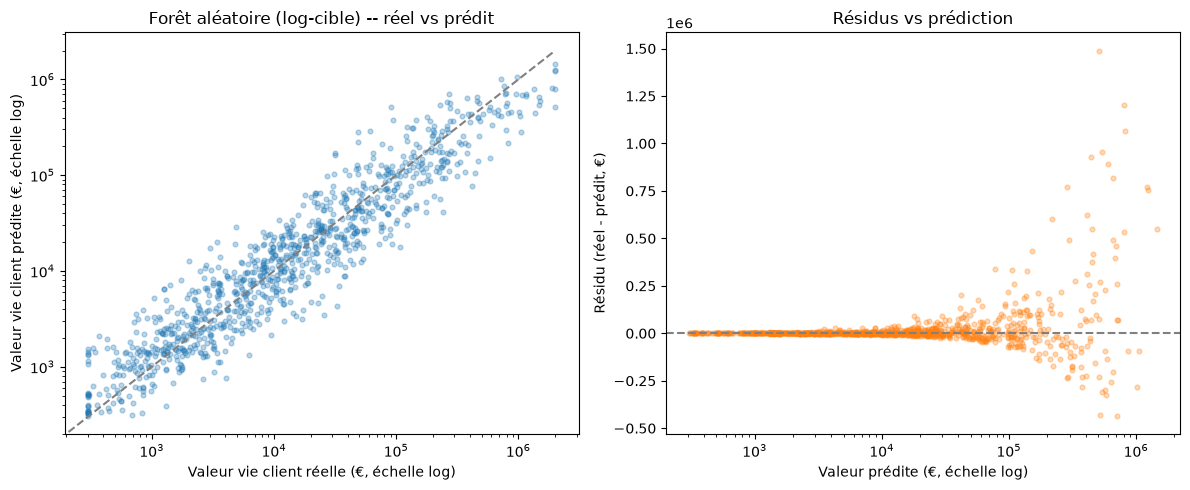

Figure enregistrée : ..\data\model\clv_reel_vs_predit.png


In [7]:
MODELE_RETENU_CLV = "Forêt aléatoire (log-cible)" if metriques_rf["mae_eur"] <= metriques_ridge["mae_eur"] else "Ridge (log-cible)"
if MODELE_RETENU_CLV.startswith("Forêt"):
    pipe_final_clv, pred_final_clv = pipe_rf_reg, pred_rf_reg
else:
    pipe_final_clv, pred_final_clv = pipe_ridge, pred_ridge

print(f"Modèle retenu (CLV) : {MODELE_RETENU_CLV} -- critère : MAE en euros")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, pred_final_clv, alpha=0.3, s=12, color="tab:blue")
lims = [0, float(max(y_test.max(), pred_final_clv.max()))]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Valeur vie client réelle (€, échelle log)")
axes[0].set_ylabel("Valeur vie client prédite (€, échelle log)")
axes[0].set_title(f"{MODELE_RETENU_CLV} -- réel vs prédit")

residus = y_test - pred_final_clv
axes[1].scatter(pred_final_clv, residus, alpha=0.3, s=12, color="tab:orange")
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_xscale("log")
axes[1].set_xlabel("Valeur prédite (€, échelle log)")
axes[1].set_ylabel("Résidu (réel - prédit, €)")
axes[1].set_title("Résidus vs prédiction")

plt.tight_layout()
scatter_path = MODEL_DIR / "clv_reel_vs_predit.png"
plt.savefig(scatter_path, dpi=120)
plt.show()
print("Figure enregistrée :", scatter_path)

## §5 — Importance des variables pour la valeur vie client

À comparer qualitativement avec le notebook 04 (churn) : les variables qui pèsent
sur la valeur d'un compte ne sont pas nécessairement celles qui pèsent sur son
risque de résiliation -- deux questions différentes, deux modèles différents,
jamais l'un comme feature de l'autre.

In [8]:
perm_clv = permutation_importance(
    pipe_final_clv, X_test, np.log1p(y_test), n_repeats=15, random_state=RANDOM_STATE,
    scoring="r2", n_jobs=-1,
)
# Remarque : la permutation importance est calculée en espace log, cohérent avec
# l'espace d'entraînement du modèle -- pas en euros bruts.

importance_clv_df = pd.DataFrame({
    "variable": feature_columns,
    "importance_moyenne": perm_clv.importances_mean,
}).sort_values("importance_moyenne", ascending=False)

print("Top 8 variables les plus importantes pour la valeur vie client :")
print(importance_clv_df.head(8).to_string(index=False))

Top 8 variables les plus importantes pour la valeur vie client :
                        variable  importance_moyenne
    revenu_mensuel_recurrent_eur            1.807529
                 anciennete_mois            0.015611
                sieges_souscrits            0.001991
                heures_usage_30j            0.001042
                  connexions_30j            0.000707
                            pays            0.000583
taux_utilisation_fonctionnalites            0.000413
                            plan            0.000250


## §6 — Persistance

In [9]:
model_path_clv = MODEL_DIR / "model_clv.joblib"
joblib.dump(pipe_final_clv, model_path_clv)

metrics_clv = {
    "cible": "valeur_vie_client_eur (régression, log1p à l'entraînement)",
    "baseline": metriques_baseline,
    "ridge_log_cible": {**metriques_ridge, "r2_cv_log_mean": round(float(cv_ridge.mean()), 3), "r2_cv_log_std": round(float(cv_ridge.std()), 3)},
    "foret_aleatoire_log_cible": {**metriques_rf, "r2_cv_log_mean": round(float(cv_rf_reg.mean()), 3), "r2_cv_log_std": round(float(cv_rf_reg.std()), 3)},
    "modele_retenu": MODELE_RETENU_CLV,
    "top_5_variables_importance_permutation": importance_clv_df.head(5).to_dict("records"),
}
with open(MODEL_DIR / "metrics_clv.json", "w", encoding="utf-8") as f:
    json.dump(metrics_clv, f, ensure_ascii=False, indent=2)

model_card_clv = f"""# Model card -- Valeur vie client (régression, cible secondaire)

**Modèle retenu :** {MODELE_RETENU_CLV}
**Cible :** `valeur_vie_client_eur`, entraînée en `log(1+x)`, prédictions retransformées en euros
**Jamais utilisée comme feature du modèle de churn** (§3.2 de l'énoncé)
**Features :** {len(feature_columns)}, identiques à celles du modèle churn (voir `gold_manifest.json`)

## Performance (jeu de test, 1000 comptes, seed=42)

| Modèle | RMSE (€) | MAE (€) | R² |
|---|---|---|---|
| Baseline (médiane) | {metriques_baseline['rmse_eur']:,.0f} | {metriques_baseline['mae_eur']:,.0f} | {metriques_baseline['r2']:.3f} |
| Ridge (log-cible) | {metriques_ridge['rmse_eur']:,.0f} | {metriques_ridge['mae_eur']:,.0f} | {metriques_ridge['r2']:.3f} |
| Forêt aléatoire (log-cible) | {metriques_rf['rmse_eur']:,.0f} | {metriques_rf['mae_eur']:,.0f} | {metriques_rf['r2']:.3f} |

## Usage prévu

Enrichir la priorisation des comptes à risque (score de churn × valeur vie client
estimée) -- voir `06_implementation_scoring.ipynb`. N'est jamais consommée par le
modèle de churn.

## Limites connues

- Cible très étalée (300 € à ~2 M€) -- le RMSE reste sensible aux comptes extrêmes
  malgré le log-transform ; le MAE est la métrique de pilotage privilégiée.
- Comme le modèle churn, n'intègre aucune contrainte de capacité opérationnelle.
"""
with open(MODEL_DIR / "model_card_clv.md", "w", encoding="utf-8") as f:
    f.write(model_card_clv)

model_manifest_clv = {
    "couche": "model",
    "sous_modele": "clv_regression",
    "processed_at_utc": PROCESSED_AT,
    "source": "data/gold/clients_churn_gold.parquet",
    "gold_version": gold_manifest.get("version"),
    "gold_sha256": gold_manifest.get("sha256_gold"),
    "modele_retenu": MODELE_RETENU_CLV,
    "random_state": RANDOM_STATE,
    "features": feature_columns,
    "cible": "valeur_vie_client_eur",
    "transformation_cible": "log1p à l'entraînement, expm1 sur les prédictions",
    "metriques": metrics_clv,
    "fichiers": {
        "modele": str(model_path_clv),
        "metriques": str(MODEL_DIR / "metrics_clv.json"),
        "model_card": str(MODEL_DIR / "model_card_clv.md"),
        "figure_reel_vs_predit": str(MODEL_DIR / "clv_reel_vs_predit.png"),
    },
}
with open(MODEL_DIR / "model_clv_manifest.json", "w", encoding="utf-8") as f:
    json.dump(model_manifest_clv, f, ensure_ascii=False, indent=2)

print("Modèle CLV enregistré  :", model_path_clv)
print("Métriques enregistrées :", MODEL_DIR / "metrics_clv.json")
print("Model card enregistrée :", MODEL_DIR / "model_card_clv.md")
print("Manifeste enregistré   :", MODEL_DIR / "model_clv_manifest.json")

Modèle CLV enregistré  : ..\data\model\model_clv.joblib
Métriques enregistrées : ..\data\model\metrics_clv.json
Model card enregistrée : ..\data\model\model_card_clv.md
Manifeste enregistré   : ..\data\model\model_clv_manifest.json


## §8 bis — Traçabilité de l'entraînement dans MLflow

Chaque exécution de ce notebook crée un **run MLflow** : paramètres du modèle retenu,
toutes les métriques numériques de `metrics_clv.json` (aplaties), artefacts (carte modèle, manifeste, graphique réel/prédit -- `model_clv.joblib` (62 Mo) reste versionné par DVC, pas dupliqué dans MLflow) et le tag
`gold_sha256` qui relie le run à la version exacte du Gold (chaîne de hash
RGPD → Bronze → Silver → Gold → modèle, cf. `data/README.md`).

Store par défaut : SQLite local `data/model/mlflow.db` (consultable avec
`mlflow ui --backend-store-uri sqlite:///data/model/mlflow.db`). Si `MLFLOW_TRACKING_URI`
est défini (serveur MLflow DagsHub), le même code trace sur le serveur distant.


In [ ]:
import os
import sys

sys.path.insert(0, str(Path("..").resolve()))
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
from src.tracking import flatten_metrics, log_training_run, resolve_tracking_uri

tracking_uri = resolve_tracking_uri(MODEL_DIR)
artefacts_mlflow = [MODEL_DIR / nom for nom in ["metrics_clv.json", "model_card_clv.md", "model_clv_manifest.json", "clv_reel_vs_predit.png"] if (MODEL_DIR / nom).exists()]

run_id = log_training_run(
    run_name=f"clv_{MODELE_RETENU_CLV}",
    params={"modele_retenu": MODELE_RETENU_CLV, "n_features": len(feature_columns), "random_state": 42, "cible": "log1p(valeur_vie_client_eur)", **{f"reg__{k}": v for k, v in pipe_final_clv.steps[-1][1].get_params().items()}},
    metrics=flatten_metrics(metrics_clv),
    tracking_uri=tracking_uri,
    gold_sha256=gold_manifest.get("sha256_gold"),
    gold_dataset_path="data/gold/clients_churn_gold.parquet",
    experiment_name="churn_saas_regression_clv",
    tags={"modele_retenu": MODELE_RETENU_CLV, "gold_version": str(gold_manifest.get("version")), "notebook": 'notebooks/05_modelisation_clv.ipynb'},
    artifacts=artefacts_mlflow,
    artifact_location=(MODEL_DIR / "mlartifacts").resolve().as_uri(),
)
print("Tracking URI :", tracking_uri if tracking_uri.startswith("http") else "store SQLite local (data/model/mlflow.db)")
print("Run MLflow   :", run_id)
print("Artefacts    :", [p.name for p in artefacts_mlflow])


## §7 — Vérification finale

In [10]:
verif_clv = pd.DataFrame([
    {"vérification": "Modèle retenu (CLV)", "résultat": MODELE_RETENU_CLV},
    {"vérification": "MAE test (€)", "résultat": f"{mean_absolute_error(y_test, pred_final_clv):,.0f}"},
    {"vérification": "R² test", "résultat": round(float(r2_score(y_test, pred_final_clv)), 3)},
    {"vérification": "R² > baseline", "résultat": r2_score(y_test, pred_final_clv) > metriques_baseline["r2"]},
    {"vérification": "sante_compte_fin_periode absente de X_clv", "résultat": "sante_compte_fin_periode" not in feature_columns},
    {"vérification": "churn absente de X_clv", "résultat": "churn" not in feature_columns},
    {"vérification": "Features identiques à X_churn", "résultat": gold_manifest["cible_secondaire_features"]["identique_a_feature_columns_modele_principal"]},
    {"vérification": "Fichiers CLV écrits dans data/model/", "résultat": sorted(p.name for p in MODEL_DIR.iterdir() if "clv" in p.name)},
])
verif_clv

,vérification,résultat
0,Modèle retenu (CLV),Forêt aléatoire (log-cible)
1,MAE test (€),"40,615"
2,R² test,0.697
3,R² > baseline,True
4,sante_compte_fin_periode absente de X_clv,True
5,churn absente de X_clv,True
6,Features identiques à X_churn,True
7,Fichiers CLV écrits dans data/model/,"[clv_reel_vs_predit.png, metrics_clv.json, mod..."


## Journal de bord — Synthèse TP7 (Régression CLV)

- **Même discipline anti-fuite que le modèle churn**, appliquée à une cible
  différente : `sante_compte_fin_periode` et `churn` exclues par disponibilité au
  scoring, pas par force de corrélation mesurée (principe posé au notebook 03,
  §8, ici simplement vérifié par assertion).
- **Cible transformée en log** pour une distribution très étalée (skew 5.6 -> 0.2)
  -- prédictions retransformées en euros avant toute métrique, pour rester
  interprétables côté métier.
- **Baseline, deux familles, sélection sur le MAE** -- même structure de démarche
  que le notebook churn, avec un critère de sélection adapté à cette cible
  (MAE plutôt que PR-AUC, non pertinent ici).
- **Facteurs de valeur vie client** lus séparément des facteurs de risque de churn
  (§5) -- les deux modèles répondent à des questions différentes et ne se
  substituent pas l'un à l'autre.
- **Cette régression n'entre jamais dans le modèle de churn** (vérifié §0 et §7) --
  elle sert uniquement à enrichir la priorisation, dans le notebook suivant.
- **Ce notebook s'arrête ici.** L'usage combiné des deux modèles (score de churn ×
  valeur vie client) pour produire une liste priorisée est le sujet de
  `06_implementation_scoring.ipynb` [C6].
